# Accuracy of estimated optimal ILL bin width and kernel size

This notebook uses the reusable tool in `demonstration/binning.py` to estimate the optimal Freedman-Diaconis bin width (`h_fd`) and optimal RBF-equivalent kernel size (`lambda_opt`) from the ILL D22 data.

Accuracy is measured as signed relative error versus a high-count reference shape: the finest native bin size (`G5_res_1_17C`) at the longest collection time. For each measured total count, the reference is recomputed with the same total count so that the comparison isolates the accuracy of estimating the signal roughness from noisy ILL data. Negative values mean the estimated width or kernel size is smaller than the reference.

In [1]:
from pathlib import Path
import os
import re
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# Reuse the compact demonstration tool developed for this project.
sys.path.insert(0, str(Path("demonstration").resolve()))
from binning import estimate_binning_scales

In [2]:
class ScatteringData:
    def __init__(self, Q, I, I_err, dQ, total_counts=None):
        index = Q > 0
        self.Q = Q[index]
        self.I = I[index]
        self.I_err = I_err[index]
        self.dQ = dQ[index]
        self.total_counts = total_counts


def load_ill_dat(path):
    path = Path(path)
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()

    total_counts = None
    for line in lines:
        match = re.search(r"Total Det Counts:\s*(\d+)", line)
        if match:
            total_counts = int(match.group(1))
            break

    for i, line in enumerate(lines):
        if line.strip().startswith("Mod_Q"):
            data_lines = lines[i + 1:]
            break
    else:
        raise ValueError(f"No data block found in {path}")

    array = np.loadtxt(data_lines)
    array = np.atleast_2d(array)
    Q, I, I_err, dQ = array.T
    return ScatteringData(Q, I, I_err, dQ, total_counts=total_counts)


def load_ill_folder(data_dir="data"):
    data_dir = Path(data_dir)
    data = defaultdict(lambda: defaultdict(dict))

    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir() or not folder.name.startswith("G5_res_"):
            continue
        parts = folder.name.split("_")
        if len(parts) < 4:
            continue
        bin_size = parts[2]
        collimation = parts[3].removesuffix("C")

        for file_path in sorted(folder.glob("*.dat")):
            match = re.match(r"^\d+_d(\d+)_c(\d+)\.dat$", file_path.name)
            if not match or match.group(1) != match.group(2):
                continue
            time_key = match.group(1).lstrip("0") or "0"
            data[bin_size][collimation][time_key] = load_ill_dat(file_path)

    return data


data = load_ill_folder("data")
print("Loaded bin sizes:", sorted(data.keys(), key=int))
print("Loaded collimations:", sorted({c for by_bin in data.values() for c in by_bin.keys()}, key=int))

Loaded bin sizes: ['1', '2', '4', '8', '16', '32']
Loaded collimations: ['8', '17']


In [3]:
def estimate_accuracy_by_count(data, fixed_collimation="17", reference_bin_size="1"):
    """Compare noisy-curve estimates to a high-count ILL reference shape.

    Reference definition:
    - use the finest native bin size and longest time as the shape reference;
    - for each measured total count, recompute alpha with that count;
    - compare the estimate from the corresponding measured curve with this
      reference estimate at the same total count.
    """
    time_keys = sorted(data[reference_bin_size][fixed_collimation], key=lambda x: int(x))
    best_time_key = time_keys[-1]
    best = data[reference_bin_size][fixed_collimation][best_time_key]

    reference_at_best_count = estimate_binning_scales(
        best.Q,
        best.I,
        window_frac = 0.25,
        polyorder = 2,
        total_counts=best.total_counts,
        intensity_error=best.I_err,
        warn_on_coarse_data=False,
    )

    rows = []
    for time_key in time_keys:
        current = data[reference_bin_size][fixed_collimation][time_key]
        estimated = estimate_binning_scales(
            current.Q,
            current.I,
            window_frac = 0.25,
            polyorder = 2,
            total_counts=current.total_counts,
            intensity_error=current.I_err,
            warn_on_coarse_data=False,
        )
        reference = estimate_binning_scales(
            best.Q,
            best.I,
            window_frac = 0.25,
            polyorder = 2,
            total_counts=current.total_counts,
            intensity_error=best.I_err,
            warn_on_coarse_data=False,
        )
        rows.append({
            "time_key": int(time_key),
            "total_counts": int(current.total_counts),
            "h_fd_est": estimated.h_fd,
            "h_fd_ref": reference.h_fd,
            "h_fd_signed_error_pct": 100.0 * (estimated.h_fd / reference.h_fd - 1.0),
            "h_fd_abs_error_pct": 100.0 * abs(estimated.h_fd / reference.h_fd - 1.0),
            "lambda_opt_est": estimated.lambda_opt,
            "lambda_opt_ref": reference.lambda_opt,
            "lambda_opt_signed_error_pct": 100.0 * (estimated.lambda_opt / reference.lambda_opt - 1.0),
            "lambda_opt_abs_error_pct": 100.0 * abs(estimated.lambda_opt / reference.lambda_opt - 1.0),
            "data_bin_width": estimated.data_bin_width,
            "estimator_window": estimated.window_length,
        })

    return rows, reference_at_best_count, best_time_key


def print_accuracy_table(rows):
    headers = [
        "count",
        "h_est",
        "h_ref",
        "h_signed_err_%",
        "lambda_est",
        "lambda_ref",
        "lambda_signed_err_%",
    ]
    print(" | ".join(headers))
    print(" | ".join(["---"] * len(headers)))
    for r in rows:
        print(
            f"{r['total_counts']:d} | "
            f"{r['h_fd_est']:.6g} | "
            f"{r['h_fd_ref']:.6g} | "
            f"{r['h_fd_signed_error_pct']:.3f} | "
            f"{r['lambda_opt_est']:.6g} | "
            f"{r['lambda_opt_ref']:.6g} | "
            f"{r['lambda_opt_signed_error_pct']:.3f}"
        )

In [4]:
fixed_collimation = "17"
rows, reference_at_best_count, best_time_key = estimate_accuracy_by_count(
    data,
    fixed_collimation=fixed_collimation,
    reference_bin_size="1",
)

print(f"Reference: collimation={fixed_collimation}, finest bin=1, longest time key={best_time_key}")
print(f"Reference total counts: {rows[-1]['total_counts']}")
print(f"Reference h_fd at best count: {reference_at_best_count.h_fd:.9g}")
print(f"Reference lambda_opt at best count: {reference_at_best_count.lambda_opt:.9g}")
print()
print_accuracy_table(rows)

Reference: collimation=17, finest bin=1, longest time key=7
Reference total counts: 895259
Reference h_fd at best count: 0.00292602028
Reference lambda_opt at best count: 0.00521199535

count | h_est | h_ref | h_signed_err_% | lambda_est | lambda_ref | lambda_signed_err_%
--- | --- | --- | --- | --- | --- | ---
1047 | 0.0273489 | 0.0277723 | -1.524 | 0.0196128 | 0.0201096 | -2.471
3007 | 0.0183147 | 0.0195381 | -6.261 | 0.0149968 | 0.0162842 | -7.906
10067 | 0.0121692 | 0.0130605 | -6.824 | 0.0117608 | 0.0127883 | -8.035
29364 | 0.00880039 | 0.00914089 | -3.725 | 0.00990904 | 0.0103236 | -4.016
98480 | 0.00610218 | 0.00610676 | -0.075 | 0.00811086 | 0.00810446 | 0.079
295961 | 0.00426225 | 0.00423171 | 0.722 | 0.00655682 | 0.0065035 | 0.820
895259 | 0.00292602 | 0.00292602 | 0.000 | 0.005212 | 0.005212 | 0.000


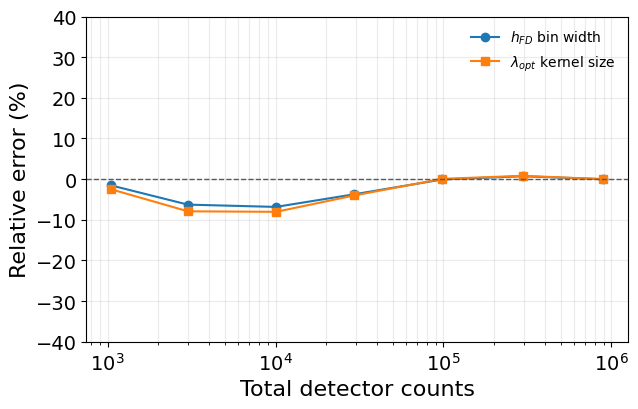

In [5]:
counts = np.array([r["total_counts"] for r in rows], dtype=float)
h_error = np.array([r["h_fd_signed_error_pct"] for r in rows])
lambda_error = np.array([r["lambda_opt_signed_error_pct"] for r in rows])

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(counts, h_error, "o-", label=r"$h_{FD}$ bin width")
ax.plot(counts, lambda_error, "s-", label=r"$\lambda_{opt}$ kernel size")
ax.set_xscale("log")
ax.set_xlabel("Total detector counts", fontsize=16)
ax.axhline(0.0, color="0.35", linewidth=1.0, linestyle="--")
ax.set_ylabel("Relative error (%)", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_ylim(-40, 40)
# ax.set_title("ILL estimate accuracy vs total count")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [6]:
# Optional: save the numeric results next to this notebook.
import csv

csv_path = Path("ILL_optimal_width_accuracy.csv")
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {csv_path.resolve()}")

Wrote C:\Users\ccu\Documents\codex_projects\MLSR_svs_upload\binning\ILL_optimal_width_accuracy.csv
